# DriveIntel

## Driver Behavior Classification using Vehicle Motion Sensor Data

### Objective

The goal of this project is to analyze vehicle motion sensor data and build machine learning models capable of classifying different driving behaviors. The project demonstrates an end-to-end data science workflow including data exploration, SQL analysis, statistical testing, feature engineering, machine learning, and deployment.

---

## Dataset

The project contains two datasets:

1. **sensor_raw.csv**
   - Raw accelerometer and gyroscope readings.
   - 1114 observations.

2. **features_14.csv**
   - Engineered statistical features extracted from windows of sensor data.
   - 1102 observations.

## Import Required Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

## Load the Datasets

In [42]:
raw_df = pd.read_csv("C:/Users/htupk/OneDrive/Desktop/DriveIntel/data/sensor_raw.csv")

features_df = pd.read_csv("C:/Users/htupk/OneDrive/Desktop/DriveIntel/data/features_14.csv")

## Preview the Datasets


In [43]:
raw_df.head()

,Target(Class),GyroX,GyroY,GyroZ,AccX,AccY,AccZ
0,1,-0.923664,3.694656,0.824427,0.162598,-0.086670,-0.969482
1,1,-0.908397,4.534351,0.832061,0.175781,-0.100586,-1.013184
2,1,0.786260,3.969466,0.587786,0.322754,-0.140381,-0.911621
3,1,0.335878,4.564885,-0.251908,0.480225,-0.226807,-0.936768
4,1,3.351145,2.694656,-0.106870,0.426025,-0.253906,-0.950195


In [44]:
features_df.head()


,Target,AccMeanX,AccMeanY,AccMeanZ,AccCovX,AccCovY,AccCovZ,AccSkewX,AccSkewY,AccSkewZ,AccKurtX,AccKurtY,AccKurtZ,AccSumX,AccSumY,AccSumZ,AccMinX,AccMinY,AccMinZ,AccMaxX,AccMaxY,AccMaxZ,AccVarX,AccVarY,AccVarZ,AccMedianX,AccMedianY,AccMedianZ,AccStdX,AccStdY,AccStdZ,GyroMeanX,GyroMeanY,GyroMeanZ,GyroCovX,GyroCovY,GyroCovZ,GyroSkewX,GyroSkewY,GyroSkewZ,GyroSumX,GyroSumY,GyroSumZ,GyroKurtX,GyroKurtY,GyroKurtZ,GyroMinX,GyroMinY,GyroMinZ,GyroMaxX,GyroMaxY,GyroMaxZ,GyroVarX,GyroVarY,GyroVarZ,GyroMedianX,GyroMedianY,GyroMedianZ,GyroStdX,GyroStdY,GyroStdZ
0,1,0.285339,-0.138611,-0.957764,0.022150,0.003975,0.001926,0.867594,-1.305868,-0.507254,-1.164806,1.239840,-0.761065,1.141357,-0.554443,-3.831055,0.162598,-0.226807,-1.013184,0.480225,-0.08667,-0.911621,0.022150,0.003975,0.001926,0.249268,-0.120483,-0.953125,0.148827,0.063049,0.043889,-0.177481,4.190840,0.498092,0.761120,0.184372,0.262859,0.225352,-0.338028,-1.727183,-0.709924,16.763359,1.992366,-4.710496,-4.035868,2.914796,-0.923664,3.694656,-0.251908,0.786260,4.564885,0.832061,0.761120,0.184372,0.262859,-0.286260,4.251908,0.706107,0.872422,0.429385,0.512697
1,1,0.313477,-0.161670,-0.956250,0.020571,0.005640,0.001456,0.002474,-0.395088,-0.677572,-2.649441,-2.649803,0.636762,1.567383,-0.808350,-4.781250,0.162598,-0.253906,-1.013184,0.480225,-0.08667,-0.911621,0.020571,0.005640,0.001456,0.322754,-0.140381,-0.950195,0.143425,0.075100,0.038159,0.528244,3.891603,0.377099,3.061080,0.585991,0.270340,1.282080,-1.069372,-0.501530,2.641221,19.458015,1.885496,1.633018,0.846742,-2.932893,-0.923664,2.694656,-0.251908,3.351145,4.564885,0.832061,3.061080,0.585991,0.270340,0.335878,3.969466,0.587786,1.749594,0.765501,0.519942
2,1,0.325195,-0.158325,-0.950155,0.017281,0.004579,0.001388,-0.354212,-0.603657,-0.984635,-1.819232,-1.472251,0.663006,1.951172,-0.949951,-5.700928,0.162598,-0.253906,-1.013184,0.480225,-0.08667,-0.911621,0.017281,0.004579,0.001388,0.353271,-0.140991,-0.943481,0.131455,0.067669,0.037253,0.189567,3.773537,0.038168,3.137076,0.552431,0.905518,1.309765,-0.378864,-1.302740,1.137405,22.641221,0.229008,1.663170,-1.192246,1.540639,-1.503817,2.694656,-1.656489,3.351145,4.564885,0.832061,3.137076,0.552431,0.905518,-0.286260,3.832061,0.240458,1.771179,0.743257,0.951587
3,1,0.336565,-0.172468,-0.937640,0.015305,0.005216,0.002253,-0.655653,-0.152454,-0.040530,-1.214712,-2.185485,0.666209,2.355957,-1.207275,-6.563477,0.162598,-0.257324,-1.013184,0.480225,-0.08667,-0.862549,0.015305,0.005216,0.002253,0.383789,-0.141602,-0.936768,0.123715,0.072222,0.047465,0.356598,4.480916,-0.102508,2.809524,3.963056,0.893127,0.861002,2.009707,-0.667798,2.496183,31.366412,-0.717557,0.434190,4.642007,-0.680104,-1.503817,2.694656,-1.656489,3.351145,8.725191,0.832061,2.809524,3.963056,0.893127,0.335878,3.969466,-0.106870,1.676163,1.990743,0.945054
4,1,0.337860,-0.164185,-0.941681,0.013132,0.005020,0.002062,-0.718488,-0.446061,0.250539,-0.666622,-1.909540,0.556116,2.702881,-1.313477,-7.533447,0.162598,-0.257324,-1.013184,0.480225,-0.08667,-0.862549,0.013132,0.005020,0.002062,0.365356,-0.140991,-0.943481,0.114596,0.070850,0.045406,0.176527,4.434160,-0.167939,2.667567,3.414394,0.799787,1.072055,2.151158,-0.388248,1.412214,35.473282,-1.343511,0.737750,5.422661,-0.817133,-1.503817,2.694656,-1.656489,3.351145,8.725191,0.832061,2.667567,3.414394,0.799787,-0.286260,4.038168,-0.179389,1.633269,1.847808,0.894308


## Dataset Information

In [45]:
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Target(Class)  1114 non-null   int64  
 1   GyroX          1114 non-null   float64
 2   GyroY          1114 non-null   float64
 3   GyroZ          1114 non-null   float64
 4   AccX           1114 non-null   float64
 5   AccY           1114 non-null   float64
 6   AccZ           1114 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 61.1 KB


In [46]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 61 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Target       1102 non-null   int64  
 1   AccMeanX     1102 non-null   float64
 2   AccMeanY     1102 non-null   float64
 3   AccMeanZ     1102 non-null   float64
 4   AccCovX      1102 non-null   float64
 5   AccCovY      1102 non-null   float64
 6   AccCovZ      1102 non-null   float64
 7   AccSkewX     1102 non-null   float64
 8   AccSkewY     1102 non-null   float64
 9   AccSkewZ     1102 non-null   float64
 10  AccKurtX     1102 non-null   float64
 11  AccKurtY     1102 non-null   float64
 12  AccKurtZ     1102 non-null   float64
 13  AccSumX      1102 non-null   float64
 14  AccSumY      1102 non-null   float64
 15  AccSumZ      1102 non-null   float64
 16  AccMinX      1102 non-null   float64
 17  AccMinY      1102 non-null   float64
 18  AccMinZ      1102 non-null   float64
 19  AccMax

## Dataset Dimensions


In [47]:
print(f"Rows: {raw_df.shape[0]}")
print(f"Columns: {raw_df.shape[1]}")

Rows: 1114
Columns: 7


In [48]:
print(f"Rows: {features_df.shape[0]}")
print(f"Columns: {features_df.shape[1]}")

Rows: 1102
Columns: 61


## Column Names


In [49]:
print(raw_df.columns.tolist())

['Target(Class)', 'GyroX', 'GyroY', 'GyroZ', 'AccX', 'AccY', 'AccZ']


In [50]:
print(features_df.columns.tolist())

['Target', 'AccMeanX', 'AccMeanY', 'AccMeanZ', 'AccCovX', 'AccCovY', 'AccCovZ', 'AccSkewX', 'AccSkewY', 'AccSkewZ', 'AccKurtX', 'AccKurtY', 'AccKurtZ', 'AccSumX', 'AccSumY', 'AccSumZ', 'AccMinX', 'AccMinY', 'AccMinZ', 'AccMaxX', 'AccMaxY', 'AccMaxZ', 'AccVarX', 'AccVarY', 'AccVarZ', 'AccMedianX', 'AccMedianY', 'AccMedianZ', 'AccStdX', 'AccStdY', 'AccStdZ', 'GyroMeanX', 'GyroMeanY', 'GyroMeanZ', 'GyroCovX', 'GyroCovY', 'GyroCovZ', 'GyroSkewX', 'GyroSkewY', 'GyroSkewZ', 'GyroSumX', 'GyroSumY', 'GyroSumZ', 'GyroKurtX', 'GyroKurtY', 'GyroKurtZ', 'GyroMinX', 'GyroMinY', 'GyroMinZ', 'GyroMaxX', 'GyroMaxY', 'GyroMaxZ', 'GyroVarX', 'GyroVarY', 'GyroVarZ', 'GyroMedianX', 'GyroMedianY', 'GyroMedianZ', 'GyroStdX', 'GyroStdY', 'GyroStdZ']


## Missing Value Analysis


In [51]:
raw_df.isnull().sum()


Target(Class)    0
GyroX            0
GyroY            0
GyroZ            0
AccX             0
AccY             0
AccZ             0
dtype: int64

In [52]:
features_df.isnull().sum()

Target         0
AccMeanX       0
AccMeanY       0
AccMeanZ       0
AccCovX        0
              ..
GyroMedianY    0
GyroMedianZ    0
GyroStdX       0
GyroStdY       0
GyroStdZ       0
Length: 61, dtype: int64

## Duplicate Value Analysis


In [53]:
print("Raw Dataset Duplicates:", raw_df.duplicated().sum())

Raw Dataset Duplicates: 0


In [54]:
print("Feature Dataset Duplicates:", features_df.duplicated().sum())

Feature Dataset Duplicates: 0


## Summary Statistics

In [55]:
raw_df.describe()

,Target(Class),GyroX,GyroY,GyroZ,AccX,AccY,AccZ
count,1114.000000,1114.000000,1114.000000,1114.000000,1114.000000,1114.000000,1114.000000
mean,2.490126,-0.829957,4.122309,1.076404,0.252417,-0.095110,-0.983215
std,1.051415,3.404297,3.252790,12.049384,0.183155,0.190407,0.098061
min,1.000000,-14.946565,-10.351145,-50.259542,-0.252686,-0.793457,-1.367920
25%,2.000000,-2.274809,2.610687,0.282443,0.132202,-0.179077,-1.031372
50%,3.000000,-0.698473,4.290076,0.961832,0.244507,-0.102295,-0.986938
75%,3.000000,0.784351,5.761450,1.992366,0.372559,-0.023010,-0.928223
max,4.000000,12.778626,16.793893,45.442748,0.747803,0.768555,-0.456787


In [56]:
features_df.describe()

,Target,AccMeanX,AccMeanY,AccMeanZ,AccCovX,AccCovY,AccCovZ,AccSkewX,AccSkewY,AccSkewZ,AccKurtX,AccKurtY,AccKurtZ,AccSumX,AccSumY,AccSumZ,AccMinX,AccMinY,AccMinZ,AccMaxX,AccMaxY,AccMaxZ,AccVarX,AccVarY,AccVarZ,AccMedianX,AccMedianY,AccMedianZ,AccStdX,AccStdY,AccStdZ,GyroMeanX,GyroMeanY,GyroMeanZ,GyroCovX,GyroCovY,GyroCovZ,GyroSkewX,GyroSkewY,GyroSkewZ,GyroSumX,GyroSumY,GyroSumZ,GyroKurtX,GyroKurtY,GyroKurtZ,GyroMinX,GyroMinY,GyroMinZ,GyroMaxX,GyroMaxY,GyroMaxZ,GyroVarX,GyroVarY,GyroVarZ,GyroMedianX,GyroMedianY,GyroMedianZ,GyroStdX,GyroStdY,GyroStdZ
count,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000,1102.000000
mean,2.490018,0.250681,-0.094582,-0.983306,0.029196,0.030323,0.009583,-0.112822,-0.099898,-0.186448,-0.425800,0.211539,0.914204,3.466799,-1.304658,-13.571818,-0.002411,-0.341816,-1.161273,0.481071,0.155418,-0.825060,0.029196,0.030323,0.009583,0.253398,-0.096628,-0.983282,0.158783,0.159459,0.092317,-0.835434,4.128180,1.066751,11.155935,10.381491,114.428756,-0.089833,-0.002665,0.160261,-11.670246,56.940130,14.858328,0.968505,0.809991,1.321276,-6.796484,-1.448061,-11.100899,4.552417,9.578954,13.362845,11.155935,10.381491,114.428756,-0.735789,4.211808,1.109295,3.142812,3.034641,8.206899
std,1.050665,0.080183,0.091875,0.026849,0.022935,0.022036,0.006485,0.698375,1.056449,0.892163,1.732597,1.802550,1.908540,1.145200,1.279057,1.215344,0.113428,0.176599,0.088215,0.126783,0.218276,0.078657,0.022935,0.022036,0.006485,0.093657,0.056115,0.026540,0.063149,0.069999,0.032577,1.112982,1.012694,6.389914,7.374181,7.085781,115.341708,0.937874,0.826034,1.394261,15.563416,14.872203,89.317927,2.075692,1.835697,2.734906,3.428237,3.210436,16.934999,2.552701,2.218312,16.113840,7.374181,7.085781,115.341708,0.844474,0.844673,1.514056,1.131295,1.083287,6.864279
min,1.000000,0.019642,-0.309535,-1.053659,0.000042,0.000070,0.000118,-2.694572,-3.429108,-3.073868,-5.683040,-4.485169,-4.258125,0.081299,-4.333496,-14.751221,-0.252686,-0.793457,-1.367920,0.056396,-0.111328,-0.971924,0.000042,0.000070,0.000118,0.018311,-0.241211,-1.054932,0.006483,0.008363,0.010881,-4.534896,-0.320611,-13.828244,0.053027,0.030970,0.026300,-3.198339,-3.518831,-3.198597,-63.488550,-4.488550,-193.595420,-4.710496,-4.035868,-3.006058,-14.946565,-10.351145,-50.259542,-0.496183,4.297710,0.832061,0.053027,0.030970,0.026300,-4.061069,-0.736641,-15.675573,0.230276,0.175983,0.162173
25%,2.000000,0.196429,-0.166037,-1.003257,0.012777,0.007605,0.004619,-0.558205,-0.866926,-0.781039,-1.455117,-1.082307,-0.401395,2.703003,-2.295715,-14.039856,-0.079590,-0.442139,-1.227783,0.395020,-0.016968,-0.878662,0.012777,0.007605,0.004619,0.198730,-0.130920,-1.001312,0.113036,0.087208,0.067967,-1.496592,3.444111,-3.907852,5.376291,5.239952,1.246986,-0.700510,-0.511914,-1.128288,-20.952290,47.181298,-54.709924,-0.339967,-0.335845,-0.361769,-9.099237,-3.091603,-26.022901,2.618321,7.763359,2.389313,5.376291,5.239952,1.246986,-1.084924,3.779580,0.759542,2.318683,2.289094,1.116685
50%,3.000000,0.254752,-0.114406,-0.984262,0.022769,0.031239,0.008100,-0.135493,-0.123392,-0.124783,-0.885571,-0.107470,0.475894,3.541870,-1.564575,-13.762329,-0.013428,-0.291016,-1.147217,0.444824,0.080566,-0.834717,0.022769,0.031239,0.008100,0.250732,-0.107178,-0.987488,0.150893,0.176746,0.090003,-0.645038,4.282443,0.968103,9.686863,8.728437,127.534036,-0.141645,-0.

## Class Distribution

In [57]:
print("Raw Dataset")
print(raw_df["Target(Class)"].value_counts().sort_index())

print("\nFeature Dataset")
print(features_df["Target"].value_counts().sort_index())

Raw Dataset
Target(Class)
1    252
2    288
3    350
4    224
Name: count, dtype: int64

Feature Dataset
Target
1    249
2    285
3    347
4    221
Name: count, dtype: int64


## Target Distribution Visualization

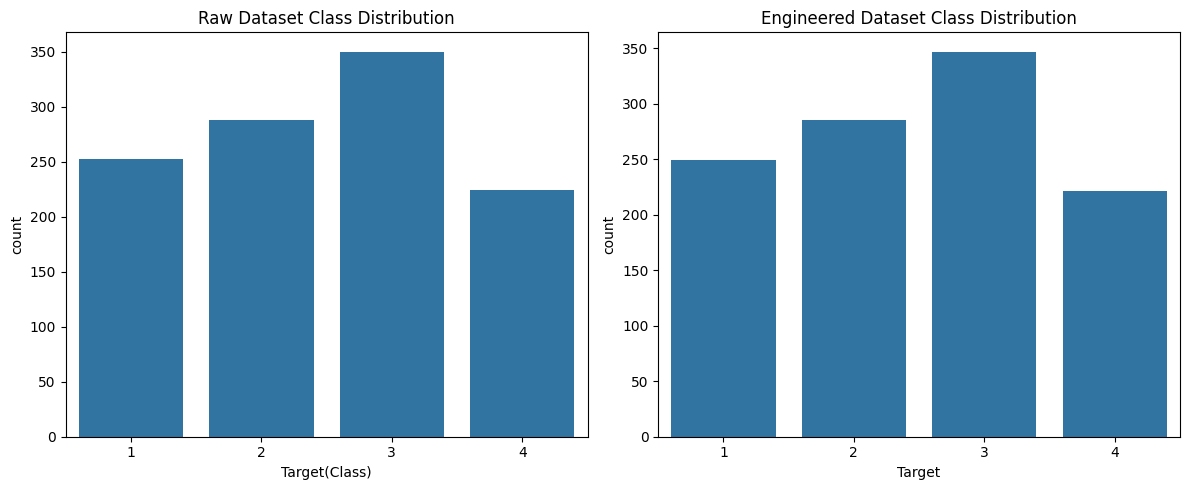

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=raw_df,
    x="Target(Class)",
    ax=axes[0]
)
axes[0].set_title("Raw Dataset Class Distribution")

sns.countplot(
    data=features_df,
    x="Target",
    ax=axes[1]
)
axes[1].set_title("Engineered Dataset Class Distribution")

plt.tight_layout()
plt.show()

## Initial Observations

- The raw dataset contains 1,114 sensor readings with 6 motion sensor features and 1 target column.
- The engineered dataset contains 1,102 observations with 60 engineered statistical features and 1 target column.
- Both datasets contain no missing values.
- All sensor features are numerical, making them directly suitable for machine learning models after preprocessing.
- The engineered dataset provides statistical summaries of sensor readings over time windows, while the raw dataset represents individual sensor measurements.